# <center> ***Projet : Prédiction de la Demande de Vélos en Libre-Service (Bike Sharing Demand)***

# <center> ***Exploration des données***

## Préparation des données

In [21]:
# Importation des bibliothèques
import pandas as pd
import seaborn as sns

# Chargement du jeu de données principal

df = pd.read_csv(r'C:\Users\imazi\OneDrive\Bureau\travail scolaire\programmation\Python\Machine learning\projet-bike-sharing\Data\train.csv',sep= ',')

# Affichage des premières lignes

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [22]:
#verifions le types des colonnes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


On voit que beaucoups de variables n'ont pas le bon type de données. Par exemple, la *variable* datetime doit être de type `datetime`. Beaucoup de variables doivent aussi être *catégorielle*,par exemple les observations de la variable *weather* est considéré comme des entiers, or , *weater* est une évaluation catégorielle de la météo (1 = Dégagé, 2 = Nuageux/Brouillard, 3 = Pluie légère/Neige, 4 = Fortes intempéries). On doit changer cela.  

In [23]:
# conversion de la date dans le bon type
df['datetime'] = pd.to_datetime(df['datetime'])
# Conversion des variables season, holiday, workingday, weather en catégorielle.
#-- traductions des catégories des variables en leurs sens veritable 

traduction_saisons = {
    1: 'Hiver',
    2: 'Printemps',
    3: 'Été',
    4: 'Automne'
}

traduction_jours_ferier = {
    0 : 'jour non férié',
    1 : 'jour férié'
}

traduction_jours_travail = {
    0 : ' week-end/jour férié',
    1 : 'jour semaine ouvrable'
}

traduction_meteo = {
    1 : 'Dégagé',
    2 : 'Nuageux/Brouillard' ,
    3 : 'légère Pluie /Neige',
    4 : 'Fortes intempéries'
}
col_cat = ['season', 'holiday', 'workingday', 'weather']
les_dicos = [traduction_saisons,traduction_jours_ferier, traduction_jours_travail, traduction_meteo]
for col,dico in zip(col_cat,les_dicos):
    df[col] = df[col].map(dico)
    df[col] = df[col].astype('category')
# verifications
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: category(4), datetime64[us](1), float64(3), int64(4)
memory usage: 723.1 KB


Nous voyons que parmis nos variables, nous avons les variables *temp* et *atemp* qui sont respectivement la température et la température "ressentie". Il est évident que ces variables sont extrêmement liées, on vérifira cela grâce au coefficient de correlation. Si cela est vrai, alors nous faisons le choix de ne garder qu'une des deux variables. En effet, garder les deux pourrait non seulement  alourdir les modèles pour rien, mais cela peut même "perturber" certains algorithmes (comme la régression linéaire) qui ne sauront plus à laquelle des deux variables attribuer le mérite des prédictions (**problème de multicolinéarité**).

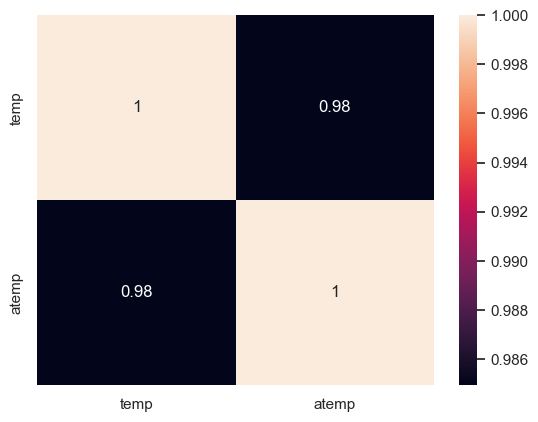

In [24]:
# on utilise la bibliothèque numpy
import numpy as np 
# On affiche la matrice de corrélations
sns.heatmap(np.corrcoef(df['temp'],df['atemp']),annot= True,xticklabels= ['temp','atemp'],yticklabels= ['temp','atemp'])
# Notre hypothèse s'avère juste, en effet, les variables sont corrélés à hauteur de 98%. 
# Nous choissions de garder que la variable atemp car plus centré sur l'experience utilisateur.
df = df.drop(columns='temp')


## Exploration des données 

In [25]:
# Importation des bibliothèques
import matplotlib.pyplot as plt
import seaborn as sns

### impact des saisons sur le nombre de vélos loués par heure

Text(0.5, 1.0, 'La location de vélos loués en fonction des saisons')

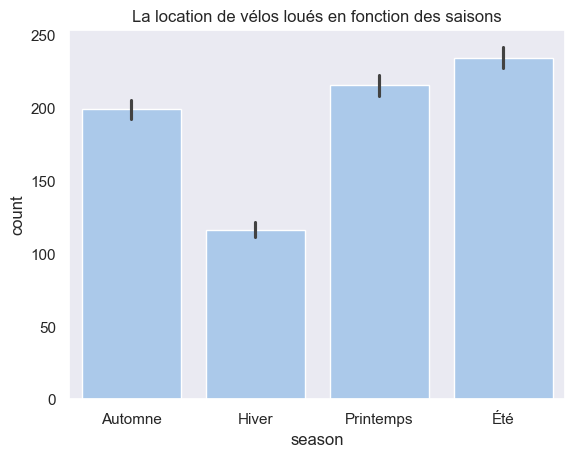

In [26]:
# Configuration esthétique
sns.set_theme(style="dark", palette="pastel")
# affichons le diagramme à barres de la location de vélos loués en fonction des saisons
sns.barplot(x= 'season', y = 'count',data= df).set_title("La location de vélos loués en fonction des saisons")

On voit bien les saisons affluancent clairement la location des vélos. On voit bien qu'en hiver, moins de personnes ont tendences à prendre le vélo, peut-être causé par les températures basses de cette période poussant les personnes à préviliger d'autres mééthodes de transports (probablement les voitures ou transports en communs). En suite, la locations de vélos est similaire durant l'automne et le printemps, bien que le nombre de locations est un peu plus haut durant le printemps.  Sans surprise, c'est en été que la location de vélo est la plus grande, un axe expliquant cela peut-être les températures plus agréables mais aussi les possibles périodes de vacances. Voyons justement l'influence de la températures sur le nombre de vélos loués.

Représentons donc le nombre de vélos loués en fonction de la **température ressentie**.

### Impact de la température 

Text(0.5, 1.0, 'Le nombre de vélos loués en fonction de la température ressentie')

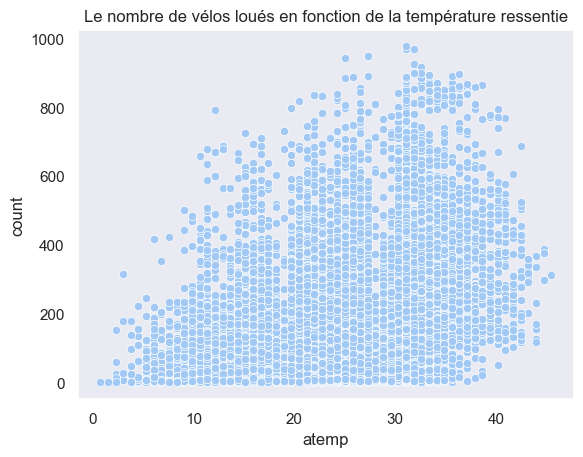

In [27]:
sns.scatterplot(x = 'atemp', y = 'count',data=df).set_title("Le nombre de vélos loués en fonction de la température ressentie")

On voit clairement que la variable *count* croît clairement en fonction de*atemps*. Néanmoins, comme notre dataset contient près de 11 000 lignes, des centaines de points se dessinent exactement au même endroit. On voit une grosse masse, mais on perd l'information de la **densité** (on ne sait pas s'il y a 5 points ou 500 points empilés au centre du nuage). Pour affiner notre analyse, essayons donc d'autres représentations.

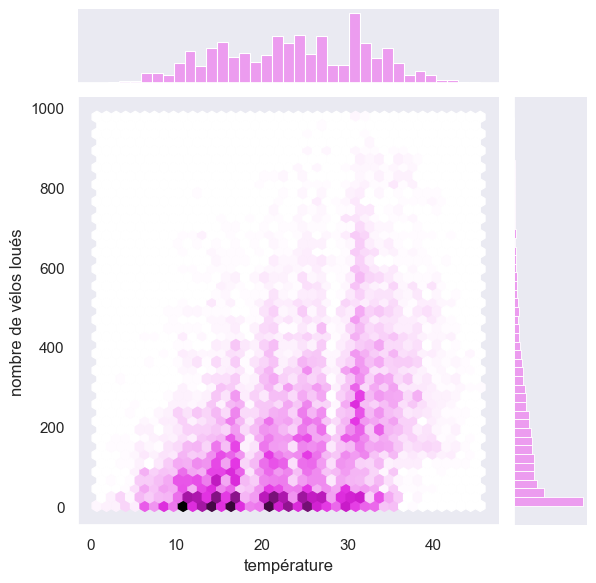

In [28]:
sns.jointplot(x='atemp', y='count', data=df, kind='hex', color = 'violet' ).set_axis_labels("température","nombre de vélos loués")

L'analyse visuelle croisant la température ressentie (*atemp*) et le volume de locations (count) confirme notre hypothèse initiale : il existe une corrélation positive claire entre la chaleur et l'utilisation des vélos. Plus la température est clémente, plus la demande grimpe.

Cependant, l'utilisation d'un graphique de densité révèle deux nuances majeures que l'on ne voyait pas avec un simple nuage de points. Premièrement, on observe un effet de saturation autour de 35°C : au-delà de ce seuil, la chaleur devient étouffante et les locations ont tendance à stagner ou chuter. Deuxièmement, la très forte concentration de données (la zone sombre) au bas du graphique nous rappelle que, quelle que soit la température idéale de la journée, une grande majorité des heures (les nuits et heures creuses) enregistre un nombre de locations proche de zéro.

<Axes: >

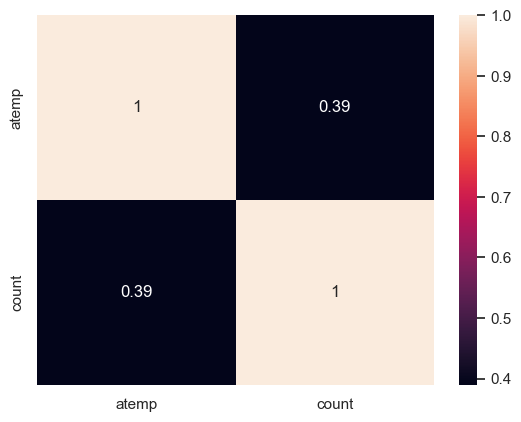

In [29]:
sns.heatmap(np.corrcoef(df['atemp'],df['count']),annot = True, xticklabels=['atemp','count'], yticklabels=['atemp','count'] )

Bien que l'on puisse s'attendre à un coefficient de corrélation plus grand, on trouve que il y a une réelle corrélation positive entre le fait de louer un vélo et une température plus élevée. De plus, le fait que le coefficient de corrélation soit "que" de 0.39 montre que la variable count ne s'explique pas seulement par la température. En effet, ce n'est pas parce que la température est idéale que l'on loue un vélo, on peut imaginer que cela ne sert à rien à 3h00 du matin.

### Impacte de la météo

On va s'interesser à l'impact de la variable météo(*weather*) sur la location de vélos.

<Axes: xlabel='weather', ylabel='count'>

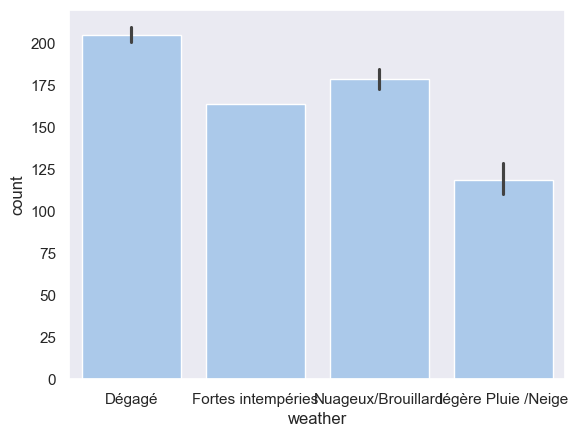

In [30]:
sns.barplot(x = 'weather', y = 'count',data = df)

En première place, il nous semble évident que si la météo est dégagée, plus de personne suspetible de prendre le vélo. De même, le fait qu'en moyenne, 180 vélos soient louée pendant un ciel relativement nuageux. A notre grande surprise il semble qu'il y a plus de vélos loués lors des fortes intempéries que lors de légères pluie. Cela mous semble vraiment suspect. Une raison qui peut expliquer cela est la méthode de fonctionnement du diagramme à barre qui calcule la moyenne de vélos loués pour chaque modalité de la variable *weather*. Immaginons qu'il n'y a eu qu'une seule et unique heure de "Fortes intempéries" pendant les deux ans d'historique de Washington D.C., et que par hasard, c'était à 18h un mardi (l'heure où tout le monde quitte le bureau en urgence pour rentrer à l'abri) ? La moyenne de cette catégorie ne sera basée que sur cette heure unique et donc que la moyenne serait artificiellement élevé. Regardons la distibution de nos observations en fonctions de la météo.

In [31]:
df['weather'].value_counts()

weather
Dégagé                 7192
Nuageux/Brouillard     2834
légère Pluie /Neige     859
Fortes intempéries        1
Name: count, dtype: int64

In [32]:
df[df['weather'] == 'Fortes intempéries']

,datetime,season,holiday,workingday,weather,atemp,humidity,windspeed,casual,registered,count
5631,2012-01-09 18:00:00,Hiver,jour non férié,jour semaine ouvrable,Fortes intempéries,11.365,86,6.0032,6,158,164


Notre hypothèse se confirme, il n'y a qu'une seule observation qui s'est déroulé lors de fortes intempéries(sûrement de fortes pluies d'hiver au vu de l'humidité de 86%) durant la quelle 164 vélos ont été loués. Cette donnée unique semble pertrber nos donnée , on pourrait choisir de la supprimer ou de l'ajouter à une autre catégorie. Ici, au vu de notre nombre de données, se débarasser de cette ligne de donnée semble la meilleure solution

In [33]:
df = df[df['weather'] != 'Fortes intempéries']
# On supprime la modalité vide à présent
df['weather'] = df['weather'].cat.remove_unused_categories()

Text(0.5, 1.0, 'Le nombre de vélos louées en fonction de la météo')

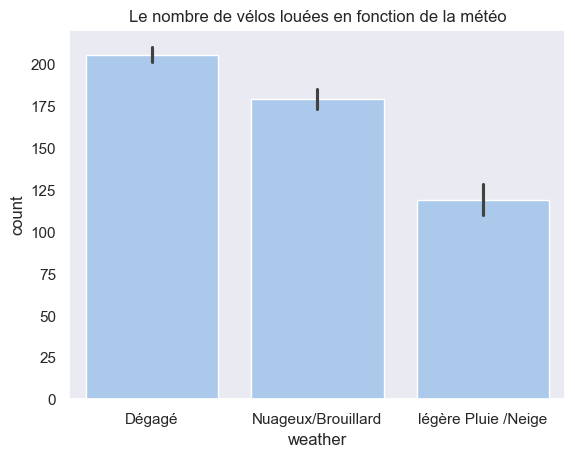

In [38]:
# On réaffiche notre barplot
sns.barplot(x = 'weather', y = 'count',data = df).set_title('Le nombre de vélos louées en fonction de la météo')

On observe bien plus la météo est dégagée, plus les personnes ont tendance à louer des vélos.

### importance de la date

On sait que les données sont récoltées toutes les heures entre 2011 et 2012. On va "découper" notre varialbe *datetime* afin de répondre aux questions suivantes: 
- Existe t-il des heures où on loue plus de Vélos (notion d'heures de pointes)?
- Nous avons la variable *season* mais pouvons nous être certain que le volume de vélos loués est uniforme durant toute la saison ou cela dépend-t-il du mois?
- La récolte de données à durer 2 ans, mais il est possible que durant la seconde année, les personnes ont loués plus de vélos, est-ce le cas ? 

In [ ]:
# On crée donc 3 autres variables: hour,year, month
df['hour'] = df['datetime'].dt.hour
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
# verification de la création
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'hour',
       'year', 'month'],
      dtype='str')

Text(0.5, 1.0, "Nombre de vélos louées en fonction de l'heure")

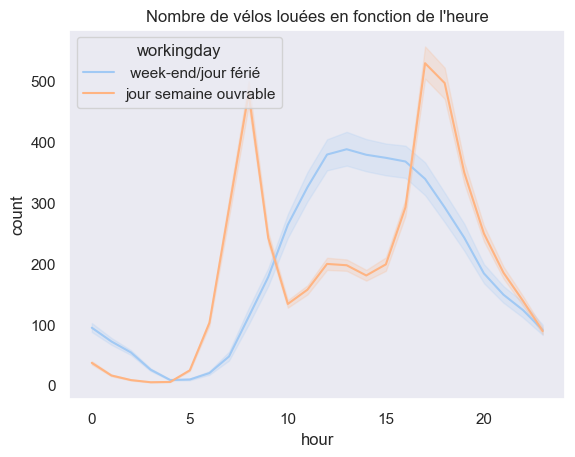

In [48]:
# On va créer la courbe de la location de vélos en fonction de l'heure, dinguant les jours de travail et week-ends et fériés
sns.lineplot(x = 'hour', y = 'count', data = df, hue= 'workingday').set_title("Nombre de vélos louées en fonction de l'heure")

L'analyse temporelle des locations révèle une dichotomie claire selon le type de journée. En semaine (jours ouvrés), la courbe illustre un phénomène classique de trajets domicile-travail, caractérisé par deux pics d'affluence très marqués aux heures de pointe (8h-9h et 17h-18h). À l'inverse, durant les week-ends et jours fériés, la dynamique change radicalement : la demande forme une courbe en cloche atteignant son apogée en début d'après-midi, ce qui suggère une transition vers un usage principalement récréatif, sportif ou touristique.

Répondons maintenant à notre seconde question: **y'a-t-il une différence réelle du nombre de locations suivant les mois dans une même saison?*Par exemple:* un doux début d'octobre et un glacial mois de décembre.**

<Axes: xlabel='month', ylabel='count'>

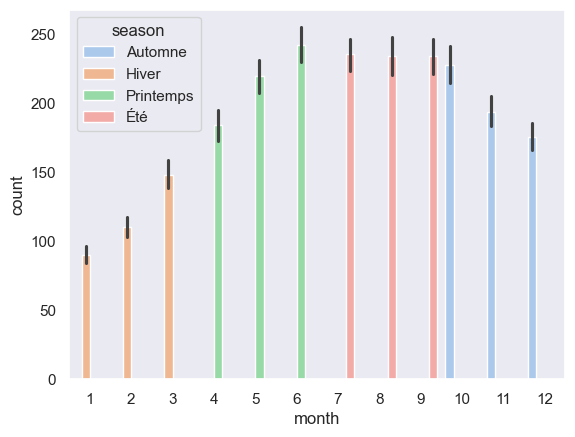

In [ ]:
sns.barplot(x ='month', y= 'count',data = df, hue = 'season').set_title("Évolution mensuelle des locations : au-delà des saisons")

L'analyse du volume de locations par mois révèle que la notion de saison est insuffisante pour capter avec précision le comportement des utilisateurs. Au sein d'une même saison (représentée par les différentes couleurs), nous observons des variations significatives. Par exemple, au printemps (en vert), la demande connaît une croissance spectaculaire entre avril et juin. De même, en automne (en bleu), la chute est drastique entre octobre et décembre.

Globalement, le volume de locations suit une courbe en cloche (une distribution presque normale) centrée sur l'été, avec le mois de juin qui s'impose comme le champion incontesté de l'année. Cette dynamique souligne la nécessité de conserver la variable 'mois' (month) dans notre modèle prédictif pour lui fournir une précision sur les transitions climatiques inter-saisonnières.

**Répondons maintenant à la dernière question que nous avons lors de notre phase exploratoire: Exsite t-il un plus grand engoument pour la location de vélos en 2012 en comparaison de 2011?**

Text(0.5, 1.0, 'Nombre de vélos loué chaque année.')

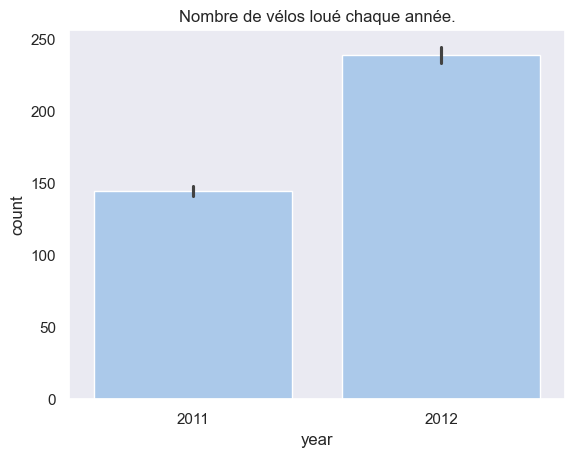

In [61]:
sns.barplot(x= 'year',y = 'count',data= df).set_title("Nombre de vélos loué chaque année.")

In [66]:
df['year'].value_counts()

year
2012    5463
2011    5422
Name: count, dtype: int64

Il semble en effet qu'il y a un essors du nombre de vélos loués en 2012 en comparaison de 2011 (240 environs contre 150). Cette différence est néanmoins à nuancer car il y a une diiférence de 41 observations entre l'année 2012 et 2011 (commande `value_count` ci-dessus) mais qui ne suffit pas à justifier la différence nette entre les deux années. 

### 🎯 Conclusion de l'Analyse Exploratoire des Données (EDA)

 Au terme de cette phase d'exploration, nous avons acquis une compréhension approfondie de la dynamique de location de vélos et préparé un jeu de données robuste pour la modélisation.

1. Comportement des utilisateurs et Météo
    
   La demande est fortement corrélée aux conditions climatiques. Les utilisateurs privilégient les températures clémentes, avec un pic d'utilisation autour de 25-30°C ressentis, suivi d'une baisse lors des chaleurs extrêmes. Les intempéries freinent logiquement les locations, l'unique observation liée à une violente tempête ayant d'ailleurs été écartée pour ne pas fausser le modèle. Afin d'éviter la multicolinéarité, nous avons conservé uniquement la température ressentie (atemp), plus représentative du choix humain que la température brute (temp).

2. Dynamiques Temporelles et Usages 
   
   Le Feature Engineering sur la date nous a permis de révéler des tendances cruciales :
   - Usage journalier : Une distinction claire existe entre les jours ouvrés (caractérisés par des trajets domicile-travail avec des pics à 8h et 17h) et les week-ends (caractérisés par un usage de loisir l'après-midi).
   - Saisonnalité fine : Le mois de juin est la période la plus faste de l'année, démontrant que le volume de location varie fortement à l'intérieur même d'une saison.
   - Croissance globale : L'année 2012 marque un essor commercial majeur par rapport à 2011, avec une forte augmentation moyenne du nombre de locations.
  

In [68]:
# On sauvegarde nos données dans un nouveaux fichier csv
df.to_csv('train_clean.csv',index= False)